In [ ]:
# =========================
# 🔷 CELL 1 — Setup + HF LLM + Paths (STABLE Phi-3 VERSION)
# =========================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# -------------------------
# Install Dependencies
# -------------------------
!pip install -q transformers datasets scikit-learn accelerate sentence-transformers tqdm spacy vaderSentiment textblob

!python -m spacy download en_core_web_sm

# -------------------------
# Imports
# -------------------------
import os, json, random, time, gc
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from transformers import pipeline

# -------------------------
# 🔥 CLEAN VRAM (CRITICAL)
# -------------------------
gc.collect()
torch.cuda.empty_cache()

# -------------------------
# CONFIG (FIXED)
# -------------------------
CONFIG = {
    "models": {
        "writer": "microsoft/phi-3-mini-4k-instruct",   # 🔥 UPDATED
        "embedding": "sentence-transformers/all-MiniLM-L6-v2",
        "nli": "roberta-large-mnli"
    },
    "thresholds": {
        "similarity": 0.75,
        "contradiction": 0.35,
        "bias_min_delta": 0.02
    },
    "rewrite": {
        "max_attempts": 5,
        "temperature_writer": 0.7
    },
    "system": {
        "seed": 42
    }
}

# -------------------------
# Seed
# -------------------------
SEED = CONFIG["system"]["seed"]
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("⚙️ Device:", DEVICE)

# -------------------------
# Load Writer LLM (PHI-3 SAFE)
# -------------------------
print("\n📥 Loading Phi-3 Mini...")

writer_pipe = pipeline(
    "text-generation",
    model=CONFIG["models"]["writer"],
    device=0 if DEVICE == "cuda" else -1,
    max_new_tokens=128
)

print("✔ Writer loaded (Phi-3 Mini)")

# -------------------------
# Paths
# -------------------------
ROOT = "/content/drive/MyDrive/AgenticNeutralizer"

PATHS = {
    "processed": f"{ROOT}/data/processed",
    "backbone": f"{ROOT}/models/bias_backbone",
    "backbone_results": f"{ROOT}/models/bias_backbone/results",
    "features": f"{ROOT}/features/derived_bias",
    "composite": f"{ROOT}/bias_objective",
    "retrieval": f"{ROOT}/retrieval",
    "rewriting": f"{ROOT}/rewriting"
}

os.makedirs(PATHS["rewriting"], exist_ok=True)

print("\n✅ Setup complete")
print("🧠 Writer:", CONFIG["models"]["writer"])

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 93.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
⚙️ Device: cuda

📥 Loading Phi-3 Mini...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


✔ Writer loaded (Phi-3 Mini)

✅ Setup complete
🧠 Writer: microsoft/phi-3-mini-4k-instruct


In [ ]:
# =========================
# 🔷 CELL 2 — Full Data + Artifact Loader (ROBUST)
# =========================

from pathlib import Path

# -------------------------
# Define Required Files
# -------------------------
FILES = {
    "train": f"{PATHS['processed']}/train.csv",
    "val": f"{PATHS['processed']}/val.csv",
    "test": f"{PATHS['processed']}/test.csv",
    "fever": f"{PATHS['processed']}/fever_corpus.jsonl",

    "pred_test": f"{PATHS['backbone_results']}/test_predictions.csv",
    "feat_test": f"{PATHS['features']}/test_features.csv",
    "comp_test": f"{PATHS['composite']}/test_composite.csv",
    "retrieval": f"{PATHS['retrieval']}/retrieval_results.csv"
}

# -------------------------
# Check File Existence
# -------------------------
print("\n🔍 Checking required files...\n")

missing_files = []

for name, path in FILES.items():
    if os.path.exists(path):
        print(f"✔ {name}: FOUND")
    else:
        print(f"❌ {name}: MISSING → {path}")
        missing_files.append((name, path))

if len(missing_files) > 0:
    raise Exception("❌ Missing required artifacts")

# -------------------------
# Load Base Data
# -------------------------
print("\n📥 Loading base datasets...")

train_df = pd.read_csv(FILES["train"])
val_df   = pd.read_csv(FILES["val"])
test_df  = pd.read_csv(FILES["test"])

# -------------------------
# Load Module Outputs
# -------------------------
print("📥 Loading model outputs...")

pred_df = pd.read_csv(FILES["pred_test"])
feat_df = pd.read_csv(FILES["feat_test"])
comp_df = pd.read_csv(FILES["comp_test"])
retr_df = pd.read_csv(FILES["retrieval"])

# -------------------------
# 🔥 CLEAN DUPLICATES (CRITICAL)
# -------------------------
pred_df = pred_df.drop_duplicates("sentence_id")
feat_df = feat_df.drop_duplicates("sentence_id")
comp_df = comp_df.drop_duplicates("sentence_id")
retr_df = retr_df.drop_duplicates("sentence_id")

# -------------------------
# 🔗 Merge Everything (TEST ONLY)
# -------------------------
print("\n🔗 Merging datasets...")

master_df = test_df.merge(pred_df, on="sentence_id", how="left", suffixes=("", "_pred"))
master_df = master_df.merge(feat_df, on="sentence_id", how="left", suffixes=("", "_feat"))
master_df = master_df.merge(comp_df, on="sentence_id", how="left", suffixes=("", "_comp"))
master_df = master_df.merge(retr_df, on="sentence_id", how="left")

# -------------------------
# 🔥 REQUIRED COLUMN VALIDATION (NEW)
# -------------------------
required_cols = [
    "text",
    "p_bias",
    "lexical_bias",
    "emotional_bias",
    "framing_bias",
    "composite_bias",
    "rewrite_required"
]

missing_cols = [c for c in required_cols if c not in master_df.columns]

if len(missing_cols) > 0:
    print("\n❌ Missing columns after merge:")
    print(missing_cols)

    print("\n📋 Available columns:")
    print(list(master_df.columns))

    raise ValueError("Feature merge failed — stopping pipeline")

print("\n✔ All required columns present")

# -------------------------
# 🔥 NULL CHECK (NEW)
# -------------------------
null_report = master_df[required_cols].isnull().sum()

if null_report.sum() > 0:
    print("\n⚠ WARNING: Null values detected")
    print(null_report)
else:
    print("✔ No null values in critical columns")

# -------------------------
# Stats
# -------------------------
print("\n📊 MASTER DATA SUMMARY")
print("Total samples:", len(master_df))
print("Rewrite required:", master_df["rewrite_required"].sum())
print("Rewrite %:", round(master_df["rewrite_required"].mean()*100, 2), "%")

# -------------------------
# Save master_df
# -------------------------
master_path = f"{PATHS['processed']}/master_test.csv"
master_df.to_csv(master_path, index=False)

print("\n💾 Saved master dataset:", master_path)


🔍 Checking required files...

✔ train: FOUND
✔ val: FOUND
✔ test: FOUND
✔ fever: FOUND
✔ pred_test: FOUND
✔ feat_test: FOUND
✔ comp_test: FOUND
✔ retrieval: FOUND

📥 Loading base datasets...
📥 Loading model outputs...

🔗 Merging datasets...

✔ All required columns present
✔ No null values in critical columns

📊 MASTER DATA SUMMARY
Total samples: 1414
Rewrite required: 424
Rewrite %: 29.99 %

💾 Saved master dataset: /content/drive/MyDrive/AgenticNeutralizer/data/processed/master_test.csv


In [ ]:
# =========================
# 🔷 CELL 3 — Model Loader (FINAL FIXED)
# =========================

import torch
import spacy
import json

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("⚙️ Device:", DEVICE)

# -------------------------
# Load Bias Backbone (RoBERTa)
# -------------------------
print("\n📥 Loading Bias Backbone...")

BACKBONE_DIR = PATHS["backbone"]

tokenizer = AutoTokenizer.from_pretrained(BACKBONE_DIR)
backbone_model = AutoModelForSequenceClassification.from_pretrained(BACKBONE_DIR)

backbone_model.to(DEVICE)
backbone_model.eval()

# -------------------------
# Load Calibration
# -------------------------
with open(f"{BACKBONE_DIR}/calibration.json") as f:
    calibration_data = json.load(f)

TEMPERATURE = calibration_data["temperature"]

# -------------------------
# Load Threshold (FULLY ROBUST)
# -------------------------
threshold_data = json.load(open(f"{PATHS['composite']}/threshold.json"))

if "threshold" in threshold_data:
    THRESHOLD = threshold_data["threshold"]
elif "optimal_threshold" in threshold_data:
    THRESHOLD = threshold_data["optimal_threshold"]
elif "optimal_composite_threshold" in threshold_data:
    THRESHOLD = threshold_data["optimal_composite_threshold"]
else:
    raise KeyError(
        f"Threshold key not found. Keys available: {list(threshold_data.keys())}"
    )

print(f"✔ Backbone loaded | Temp={TEMPERATURE:.3f}")
print(f"✔ Loaded threshold: {THRESHOLD:.4f}")

# -------------------------
# Load Sentence Embedding Model (SBERT)
# -------------------------
print("\n📥 Loading SBERT...")

sbert_model = SentenceTransformer(CONFIG["models"]["embedding"], device=DEVICE)

print("✔ SBERT loaded")

# -------------------------
# Load NLI Model
# -------------------------
print("\n📥 Loading NLI model...")

nli_tokenizer = AutoTokenizer.from_pretrained(CONFIG["models"]["nli"])
nli_model = AutoModelForSequenceClassification.from_pretrained(CONFIG["models"]["nli"])

nli_model.to(DEVICE)
nli_model.eval()

print("✔ NLI model loaded")

# -------------------------
# Load spaCy
# -------------------------
print("\n📥 Loading spaCy...")

nlp = spacy.load("en_core_web_sm", disable=["ner"])

print("✔ spaCy loaded")

# -------------------------
# Quick Test Forward Pass (Sanity Check)
# -------------------------
print("\n🧪 Running sanity forward pass...")

test_text = "The government strongly criticized the controversial decision."

inputs = tokenizer(
    test_text,
    return_tensors="pt",
    truncation=True,
    padding=True
).to(DEVICE)

with torch.no_grad():
    logits = backbone_model(**inputs).logits
    prob = torch.sigmoid(logits / TEMPERATURE).item()

print(f"✔ Test p_bias: {prob:.4f}")

⚙️ Device: cuda

📥 Loading Bias Backbone...


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

✔ Backbone loaded | Temp=0.929
✔ Loaded threshold: 0.3042

📥 Loading SBERT...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large-mnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✔ NLI model loaded

📥 Loading spaCy...
✔ spaCy loaded

🧪 Running sanity forward pass...
✔ Test p_bias: 0.2551


In [ ]:
# =========================
# 🔷 CELL 4 — Writer Agent (IMPROVED)
# =========================

def extract_text(output, prompt):
    full = output[0]["generated_text"]

    if full.startswith(prompt):
        cleaned = full[len(prompt):].strip()
    else:
        cleaned = full.strip()

    cleaned = cleaned.replace("Rewrite neutrally:", "").strip()
    cleaned = cleaned.split("\n")[0].strip()

    return cleaned


def writer_agent(row):

    evidence = []
    for i in range(1, 6):
        ev = row.get(f"evidence_{i}", "")
        sim = row.get(f"cos_sim_{i}", 0)

        if isinstance(ev, str) and sim >= 0.25:
            evidence.append((sim, ev))

    # 🔥 Sort by similarity (NEW)
    evidence = sorted(evidence, key=lambda x: x[0], reverse=True)
    evidence = [ev for _, ev in evidence[:3]]

    evidence_text = "\n".join(evidence)

    # 🔥 Stronger constraints (critical fix)
    prompt = f"""
Rewrite neutrally:

Original: {row['text']}

Bias:
p={row['p_bias']:.3f}
lex={row.get('lexical_bias',0):.3f}
emo={row.get('emotional_bias',0):.3f}
frame={row.get('framing_bias',0):.3f}

Evidence:
{evidence_text}

Rules:
- Keep meaning EXACTLY
- DO NOT change factual content under any circumstance
- Preserve all key entities, numbers, and claims
- Remove bias aggressively
- Use neutral tone
- One sentence only
"""

    out = writer_pipe(
        prompt,
        max_new_tokens=64,
        do_sample=True,
        temperature=0.5,   # more stable
        top_p=0.9
    )

    clean = extract_text(out, prompt)

    return clean, None


print("✔ Writer agent updated")

✔ Writer agent updated


In [ ]:
# =========================
# 🔷 CELL 5 — Verification Engine (CONTRADICTION PRIORITY)
# =========================

import torch.nn.functional as F

print("\n🔧 Initializing Verification Engine...\n")

def compute_similarity(text1, text2):

    emb1 = sbert_model.encode(text1, convert_to_tensor=True, normalize_embeddings=True)
    emb2 = sbert_model.encode(text2, convert_to_tensor=True, normalize_embeddings=True)

    return float(F.cosine_similarity(emb1, emb2, dim=0))


def compute_contradiction(text1, text2):

    inputs = nli_tokenizer(
        text1,
        text2,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(DEVICE)

    with torch.no_grad():
        logits = nli_model(**inputs).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    return float(probs[0])  # contradiction


def compute_bias(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(DEVICE)

    with torch.no_grad():
        logits = backbone_model(**inputs).logits
        prob = torch.sigmoid(logits / TEMPERATURE).item()

    return prob


def verify_rewrite(original, rewrite, bias_before):

    sim = compute_similarity(original, rewrite)
    contradiction = compute_contradiction(original, rewrite)
    bias_after = compute_bias(rewrite)

    bias_delta = bias_before - bias_after

    sim_threshold = 0.70 if bias_delta >= 0.1 else 0.75
    nli_threshold = CONFIG["thresholds"]["contradiction"]

    sim_pass = sim >= sim_threshold
    nli_pass = contradiction <= nli_threshold
    bias_pass = bias_delta >= CONFIG["thresholds"]["bias_min_delta"]

    return {
        "similarity": sim,
        "contradiction": contradiction,
        "bias_before": bias_before,
        "bias_after": bias_after,
        "bias_delta": bias_delta,
        "sim_pass": sim_pass,
        "nli_pass": nli_pass,
        "bias_pass": bias_pass,
        "all_pass": sim_pass and nli_pass and bias_pass
    }

print("✅ Verification ready")


🔧 Initializing Verification Engine...

✅ Verification ready


In [ ]:
# =========================
# 🔷 CELL 6 — Agent Loop (SAFE + REUSABLE)
# =========================

import os
import pandas as pd

final_path = f"{PATHS['rewriting']}/final_all_424.csv"

if os.path.exists(final_path):
    print("✔ Loading existing multi-agent results...")
    final_df = pd.read_csv(final_path)

else:
    print("\n🚀 Running FULL multi-agent pipeline...\n")

    df = master_df[master_df["rewrite_required"] == True].copy()

    def compute_score(sim, bias_delta, contradiction):
        return (
            0.35 * sim +
            0.50 * bias_delta -
            0.40 * contradiction
        )

    results = []

    for _, row in tqdm(df.iterrows(), total=len(df)):

        sid = row["sentence_id"]
        original = row["text"]
        bias_before = row["p_bias"]

        best_score = -999
        best_rewrite = original
        best_metrics = None
        accepted = False

        for attempt in range(1, CONFIG["rewrite"]["max_attempts"]+1):

            rewrite, _ = writer_agent(row)

            if not rewrite or len(rewrite.strip()) < 5:
                continue

            verify = verify_rewrite(original, rewrite, bias_before)

            sim = verify["similarity"]
            bias_delta = verify["bias_delta"]
            contradiction = verify["contradiction"]

            score = compute_score(sim, bias_delta, contradiction)

            if score > best_score:
                best_score = score
                best_rewrite = rewrite
                best_metrics = verify

            if verify["all_pass"] or score > 0.45:
                accepted = True
                break

        results.append({
            "sentence_id": sid,
            "original": original,
            "final_rewrite": best_rewrite,
            "accepted": accepted,
            "similarity": best_metrics["similarity"] if best_metrics else None,
            "bias_before": bias_before,
            "bias_after": best_metrics["bias_after"] if best_metrics else None,
            "bias_delta": best_metrics["bias_delta"] if best_metrics else None,
            "contradiction": best_metrics["contradiction"] if best_metrics else None
        })

    final_df = pd.DataFrame(results)
    final_df.to_csv(final_path, index=False)

    print("\n✅ Multi-agent results saved:", final_path)

print("Final DF shape:", final_df.shape)

✔ Loading existing multi-agent results...
Final DF shape: (424, 9)


In [ ]:
# =========================
# 🔷 LOAD EXISTING REWRITES (UPDATED FOR FILE B)
# =========================

final_path = f"{PATHS['rewriting']}/final_all_424.csv"

if not os.path.exists(final_path):
    raise FileNotFoundError(
        f"❌ Missing file: {final_path}\n"
        "Run Cell 6 first."
    )

# -------------------------
# Load rewrites
# -------------------------
final_df = pd.read_csv(final_path)

print("✔ Loaded final_all_424.csv")
print("Samples:", len(final_df))

# -------------------------
# Merge with master_df
# -------------------------
rewrite_df = master_df.merge(
    final_df,
    on="sentence_id",
    how="inner"
)

print("✔ Created rewrite_df")
print("Shape:", rewrite_df.shape)

# -------------------------
# Sanity check
# -------------------------
if "final_rewrite" not in rewrite_df.columns:
    raise ValueError("❌ final_rewrite column missing")

print("\n✅ Ready for evaluation (Cell 7)")

✔ Loaded final_all_424.csv
Samples: 424
✔ Created rewrite_df
Shape: (424, 46)

✅ Ready for evaluation (Cell 7)


In [ ]:
# =========================
# 🔷 CELL 6.1 — Rewrite Sanity Check
# =========================

print("\n🔍 Checking first few rewrites...\n")

for i in range(min(5, len(rewrite_df))):
    row = rewrite_df.iloc[i]

    print("-----")
    print("ORIGINAL:", row["text"])
    print("REWRITE :", row["final_rewrite"])

    if "Rewrite neutrally" in str(row["final_rewrite"]):
        print("❌ STILL BROKEN — PROMPT LEAK DETECTED")
    else:
        print("✔ Clean rewrite")

    print()


🔍 Checking first few rewrites...

-----
ORIGINAL: YouTube is making clear there will be no “birtherism” on its platform during this year’s U.S. presidential election – a belated response to a type of conspiracy theory more prevalent in the 2012 race.
REWRITE : Neutral:
✔ Clean rewrite

-----
ORIGINAL: The increasingly bitter dispute between American women’s national soccer team and the U.S. Soccer Federation spilled onto the field Wednesday night when players wore their warm-up jerseys inside outin a protest before their 3-1 victory over Japan.
REWRITE : Rewritten: The U.S. Soccer Federation and the American women's national soccer team had a disagreement, which was expressed by the players wearing their warm-up jerseys inside out before their match against Japan, resulting in a 3-1 victory.
✔ Clean rewrite

-----
ORIGINAL: A professor who teaches climate change classes — a subject some would question as a legitimate area of study — said she has seen students who suffer fear, grief, s

In [ ]:
# =========================
# 🔷 CELL 7 — Rewrite Evaluation (CORE METRICS)
# =========================

print("\n📊 Running evaluation on rewrites...\n")

eval_rows = []

for _, row in tqdm(rewrite_df.iterrows(), total=len(rewrite_df)):

    if not isinstance(row.get("final_rewrite"), str):
        continue

    original = row["text"]
    rewrite  = row["final_rewrite"]

    # -------------------------
    # Compute metrics
    # -------------------------
    sim = compute_similarity(original, rewrite)
    contradiction = compute_contradiction(original, rewrite)

    bias_before = row["p_bias"]
    bias_after  = compute_bias(rewrite)

    bias_delta = bias_before - bias_after

    # -------------------------
    # Store
    # -------------------------
    eval_rows.append({
        "sentence_id": row["sentence_id"],
        "original": original,
        "rewrite": rewrite,

        "bias_before": bias_before,
        "bias_after": bias_after,
        "bias_delta": bias_delta,

        "similarity": sim,
        "contradiction": contradiction,

        "accepted": row.get("accepted", False)
    })


eval_df = pd.DataFrame(eval_rows)

print("✔ Evaluation complete")
print("Samples evaluated:", len(eval_df))


📊 Running evaluation on rewrites...



100%|██████████| 424/424 [00:20<00:00, 20.51it/s]

✔ Evaluation complete
Samples evaluated: 424


In [ ]:
# =========================
# 🔷 CELL 7.5 — Single-Agent Baseline (SAFE)
# =========================

import os
import pandas as pd

single_path = f"{PATHS['rewriting']}/single_agent_424.csv"

if os.path.exists(single_path):
    print("✔ Loading existing single-agent baseline...")
    single_df = pd.read_csv(single_path)

else:
    print("\n🤖 Generating SINGLE-AGENT baseline...\n")

    df = master_df[master_df["rewrite_required"] == True].copy()

    single_rows = []

    for _, row in tqdm(df.iterrows(), total=len(df)):

        original = row["text"]

        rewrite, _ = writer_agent(row)

        if not rewrite or len(rewrite.strip()) < 5:
            continue

        sim = compute_similarity(original, rewrite)
        contradiction = compute_contradiction(original, rewrite)

        bias_before = row["p_bias"]
        bias_after  = compute_bias(rewrite)

        bias_delta = bias_before - bias_after

        single_rows.append({
            "sentence_id": row["sentence_id"],
            "original": original,
            "single_rewrite": rewrite,
            "similarity": sim,
            "bias_delta": bias_delta,
            "contradiction": contradiction
        })

    single_df = pd.DataFrame(single_rows)
    single_df.to_csv(single_path, index=False)

    print("✔ Single-agent results saved:", single_path)

print("Single DF shape:", single_df.shape)

✔ Loading existing single-agent baseline...
Single DF shape: (424, 6)


In [ ]:
# =========================
# 🔷 CELL 7.6 — Merge Systems
# =========================

multi_df = eval_df.copy()

multi_df = multi_df.rename(columns={
    "similarity": "multi_similarity",
    "bias_delta": "multi_bias_delta",
    "contradiction": "multi_contradiction"
})

single_df = single_df.rename(columns={
    "similarity": "single_similarity",
    "bias_delta": "single_bias_delta",
    "contradiction": "single_contradiction"
})

compare_df = multi_df.merge(single_df, on="sentence_id")

print("✔ Comparison dataframe ready")
print(compare_df.head())

✔ Comparison dataframe ready
  sentence_id                                         original_x  \
0      0_mbic  YouTube is making clear there will be no “birt...   
1      1_mbic  The increasingly bitter dispute between Americ...   
2      3_mbic  A professor who teaches climate change classes...   
3      4_mbic  Looking around the United States, there is nev...   
4      6_mbic  The Republican president assumed he was helpin...   

                                             rewrite  bias_before  bias_after  \
0                                           Neutral:     0.740888    0.263455   
1  Rewritten: The U.S. Soccer Federation and the ...     0.538899    0.297925   
2                                           Revised:     0.420229    0.261327   
3                                         Rewritten:     0.792506    0.268454   
4  Revised: The Republican president's approach t...     0.791179    0.372299   

   multi_bias_delta  multi_similarity  multi_contradiction  accepted  \
0  

In [ ]:
# =========================
# 🔷 CELL 8 — Aggregate Results
# =========================

print("\n📈 Aggregating results...\n")

total = len(eval_df)

accepted_rate = eval_df["accepted"].mean()

avg_bias_delta = eval_df["bias_delta"].mean()
avg_similarity = eval_df["similarity"].mean()
avg_contradiction = eval_df["contradiction"].mean()

print("===== 📊 OVERALL METRICS =====")
print(f"Total Samples        : {total}")
print(f"Acceptance Rate      : {accepted_rate:.3f}")
print(f"Avg Bias Reduction   : {avg_bias_delta:.4f}")
print(f"Avg Similarity       : {avg_similarity:.4f}")
print(f"Avg Contradiction    : {avg_contradiction:.4f}")


📈 Aggregating results...

===== 📊 OVERALL METRICS =====
Total Samples        : 424
Acceptance Rate      : 0.149
Avg Bias Reduction   : 0.3105
Avg Similarity       : 0.2695
Avg Contradiction    : 0.3019


In [ ]:
# =========================
# 🔷 CELL 9 — Success / Failure Breakdown
# =========================

accepted_df = eval_df[eval_df["accepted"] == True]
rejected_df = eval_df[eval_df["accepted"] == False]

print("\n📊 BREAKDOWN\n")

print("✔ Accepted:", len(accepted_df))
print("❌ Rejected:", len(rejected_df))

if len(accepted_df) > 0:
    print("\n--- Accepted Stats ---")
    print("Bias Δ:", accepted_df["bias_delta"].mean())
    print("Sim   :", accepted_df["similarity"].mean())

if len(rejected_df) > 0:
    print("\n--- Rejected Stats ---")
    print("Bias Δ:", rejected_df["bias_delta"].mean())
    print("Sim   :", rejected_df["similarity"].mean())


📊 BREAKDOWN

✔ Accepted: 63
❌ Rejected: 361

--- Accepted Stats ---
Bias Δ: 0.3020507146253331
Sim   : 0.8207221144721621

--- Rejected Stats ---
Bias Δ: 0.31191692433147344
Sim   : 0.17325341099888664


In [ ]:
# =========================
# 🔷 CELL 10 — Save Outputs
# =========================

eval_path = f"{PATHS['rewriting']}/evaluation_results.csv"

eval_df.to_csv(eval_path, index=False)

print("\n💾 Saved evaluation results:")
print(eval_path)


💾 Saved evaluation results:
/content/drive/MyDrive/AgenticNeutralizer/rewriting/evaluation_results.csv


In [ ]:
# =========================
# 🔷 CELL 11 — Sample Outputs (Manual Inspection)
# =========================

print("\n🔍 Sample outputs:\n")

sample_df = eval_df.sample(min(5, len(eval_df)))

for _, row in sample_df.iterrows():
    print("-----")
    print("ORIGINAL:", row["original"])
    print("REWRITE :", row["rewrite"])
    print(f"Bias Δ  : {row['bias_delta']:.3f}")
    print(f"Sim     : {row['similarity']:.3f}")
    print(f"Accept  : {row['accepted']}")
    print()


🔍 Sample outputs:

-----
ORIGINAL: The votes come as a new conservative majority on the nation’s highest court has made abortion rights supporters nervous.
REWRITE : Revised:
Bias Δ  : 0.138
Sim     : 0.123
Accept  : False

-----
ORIGINAL: “The findings of the special counsel conclusively refute your past and present assertions and have exposed you as having abused your position to knowingly promote false information, having damaged the integrity of this committee, and undermined faith in U.S. government institutions,” Representative K. Michael Conaway, Republican of Texas, said to Mr. Schiff.
REWRITE : Revised:
Bias Δ  : 0.230
Sim     : 0.206
Accept  : False

-----
ORIGINAL: He lied about matters large and small. He refused to shake House Speaker Nancy Pelosi's outstretched hand. He talked up a divisive culture war.
REWRITE : Rewritten: He declined to shake House Speaker Nancy Pelosi's hand. He was involved in discussions related to cultural debates.
Bias Δ  : 0.293
Sim     : 0.600
A


📊 Generating all comparison plots...



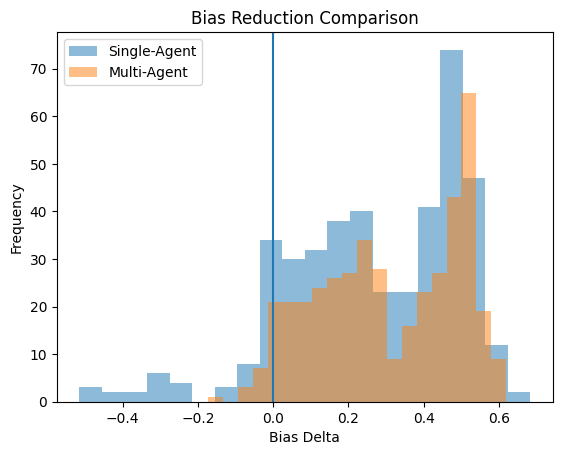

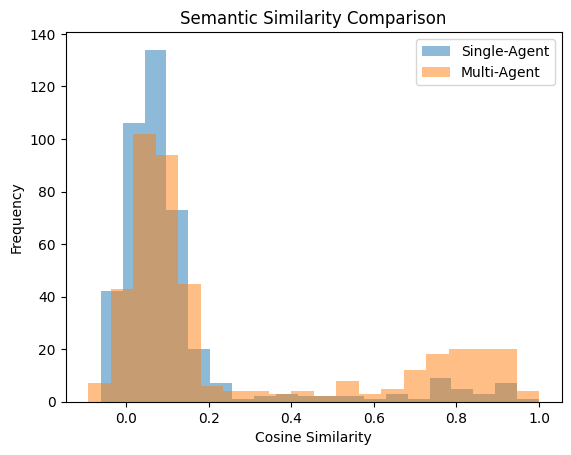

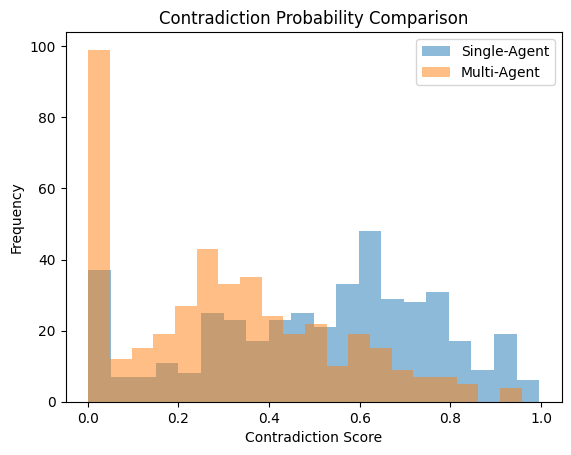

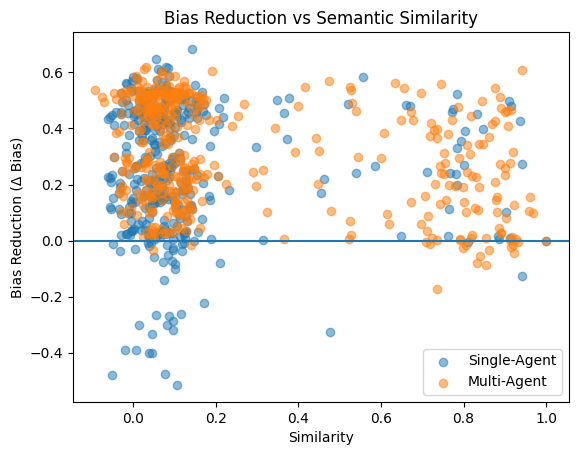

/tmp/ipykernel_3427/1115297540.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Single-Agent", "Multi-Agent"])


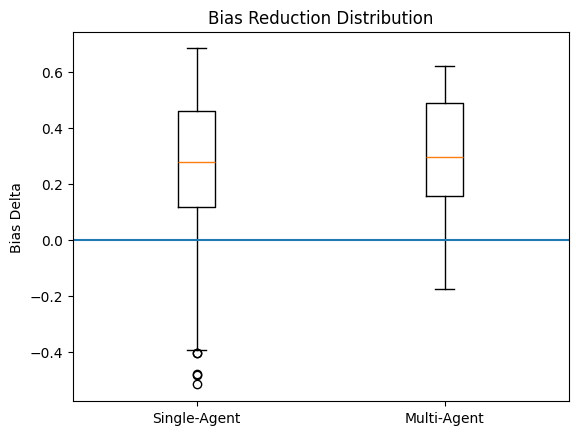

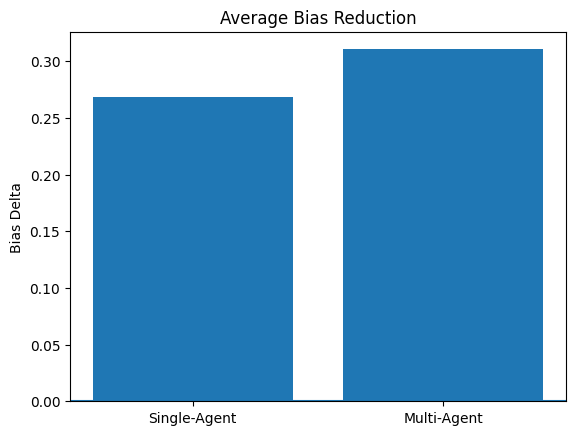

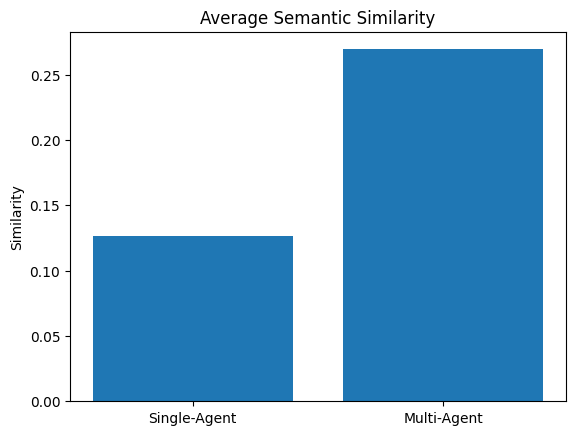

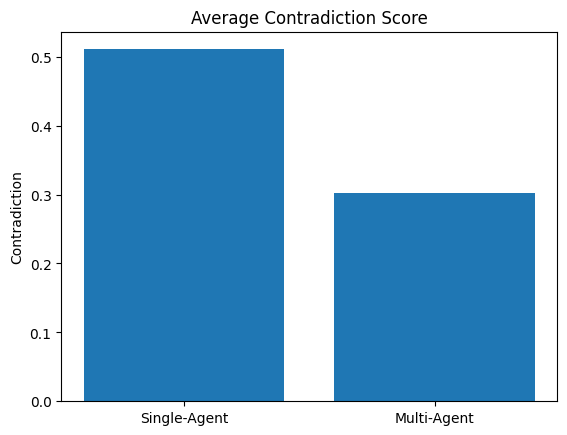

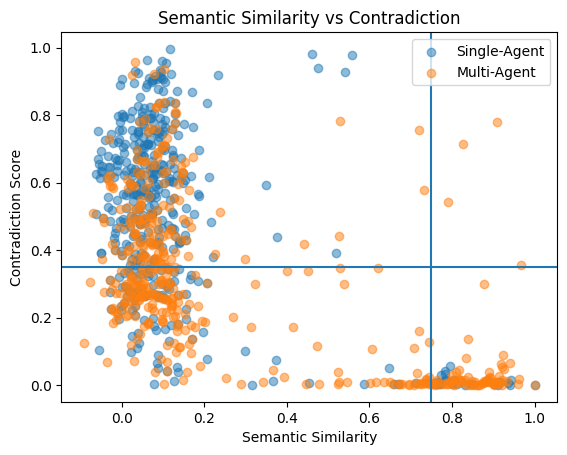

✅ All plots generated successfully


In [ ]:
# =========================
# 🔷 CELL — ALL PLOTS (SINGLE vs MULTI AGENT) [UPDATED]
# =========================

import matplotlib.pyplot as plt

print("\n📊 Generating all comparison plots...\n")

# -------------------------
# 1. Bias Reduction Histogram
# -------------------------
plt.figure()
plt.hist(compare_df["single_bias_delta"], bins=20, alpha=0.5, label="Single-Agent")
plt.hist(compare_df["multi_bias_delta"], bins=20, alpha=0.5, label="Multi-Agent")
plt.title("Bias Reduction Comparison")
plt.xlabel("Bias Delta")
plt.ylabel("Frequency")
plt.legend()
plt.axvline(0)  # important reference line
plt.show()


# -------------------------
# 2. Similarity Histogram
# -------------------------
plt.figure()
plt.hist(compare_df["single_similarity"], bins=20, alpha=0.5, label="Single-Agent")
plt.hist(compare_df["multi_similarity"], bins=20, alpha=0.5, label="Multi-Agent")
plt.title("Semantic Similarity Comparison")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.legend()
plt.show()


# -------------------------
# 3. Contradiction Histogram
# -------------------------
plt.figure()
plt.hist(compare_df["single_contradiction"], bins=20, alpha=0.5, label="Single-Agent")
plt.hist(compare_df["multi_contradiction"], bins=20, alpha=0.5, label="Multi-Agent")
plt.title("Contradiction Probability Comparison")
plt.xlabel("Contradiction Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()


# -------------------------
# 4. Scatter: Bias vs Similarity
# -------------------------
plt.figure()
plt.scatter(
    compare_df["single_similarity"],
    compare_df["single_bias_delta"],
    alpha=0.5,
    label="Single-Agent"
)

plt.scatter(
    compare_df["multi_similarity"],
    compare_df["multi_bias_delta"],
    alpha=0.5,
    label="Multi-Agent"
)

plt.xlabel("Similarity")
plt.ylabel("Bias Reduction (Δ Bias)")
plt.title("Bias Reduction vs Semantic Similarity")
plt.legend()
plt.axhline(0)  # shows improvement vs failure
plt.show()


# -------------------------
# 5. Boxplot — Bias Reduction
# -------------------------
plt.figure()
data = [
    compare_df["single_bias_delta"],
    compare_df["multi_bias_delta"]
]

plt.boxplot(data, labels=["Single-Agent", "Multi-Agent"])
plt.title("Bias Reduction Distribution")
plt.ylabel("Bias Delta")
plt.axhline(0)  # critical reference line
plt.show()


# -------------------------
# 6. Bar Chart — Mean Comparison
# -------------------------
labels = ["Single-Agent", "Multi-Agent"]

bias_means = [
    compare_df["single_bias_delta"].mean(),
    compare_df["multi_bias_delta"].mean()
]

sim_means = [
    compare_df["single_similarity"].mean(),
    compare_df["multi_similarity"].mean()
]

contr_means = [
    compare_df["single_contradiction"].mean(),
    compare_df["multi_contradiction"].mean()
]

# Bias
plt.figure()
plt.bar(labels, bias_means)
plt.title("Average Bias Reduction")
plt.ylabel("Bias Delta")
plt.axhline(0)
plt.show()

# Similarity
plt.figure()
plt.bar(labels, sim_means)
plt.title("Average Semantic Similarity")
plt.ylabel("Similarity")
plt.show()

# Contradiction
plt.figure()
plt.bar(labels, contr_means)
plt.title("Average Contradiction Score")
plt.ylabel("Contradiction")
plt.show()


# -------------------------
# 7. NEW — Similarity vs Contradiction (CRITICAL PLOT)
# -------------------------
plt.figure()

# Single-Agent
plt.scatter(
    compare_df["single_similarity"],
    compare_df["single_contradiction"],
    alpha=0.5,
    label="Single-Agent"
)

# Multi-Agent
plt.scatter(
    compare_df["multi_similarity"],
    compare_df["multi_contradiction"],
    alpha=0.5,
    label="Multi-Agent"
)

plt.xlabel("Semantic Similarity")
plt.ylabel("Contradiction Score")
plt.title("Semantic Similarity vs Contradiction")

# Reference lines (very important for interpretation)
plt.axhline(0.35)  # your contradiction threshold
plt.axvline(0.75)  # your similarity threshold

plt.legend()
plt.show()


print("✅ All plots generated successfully")


📊 RUNNING FULL EVALUATION SUITE...

🔷 1. BIAS DETECTION METRICS

⚠ No ground truth labels found — skipping bias detection evaluation


🔷 2. REWRITING PERFORMANCE

Avg Bias Before : 0.6196
Avg Bias After  : 0.3091
Bias Reduction  : 0.3105
Bias Reduction %: 46.25%
Success Rate    : 14.86%



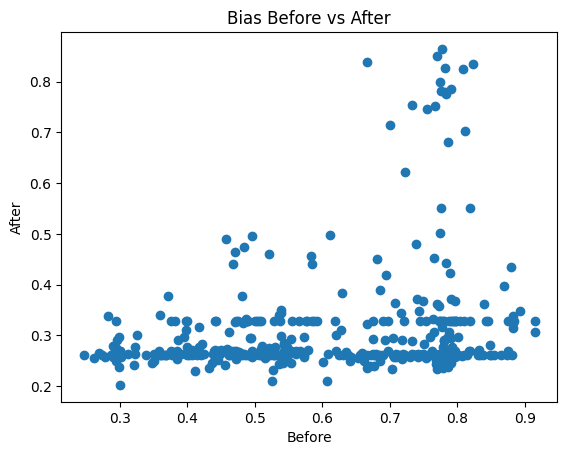

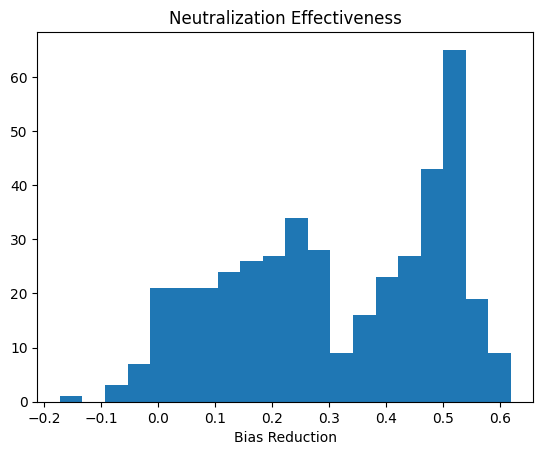


🔷 3. SEMANTIC CONSISTENCY

Average Similarity: 0.2695


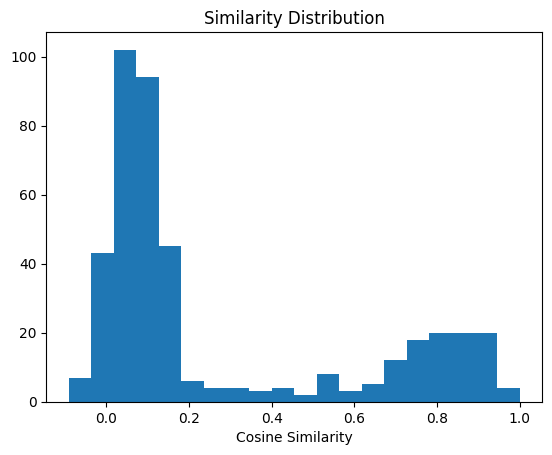


🔷 4. VERIFICATION RESULTS

Contradiction Rate : 31.37%
Entailment Rate    : 34.67%
Neutral Rate       : 33.96%
Validation Accuracy: 14.86%



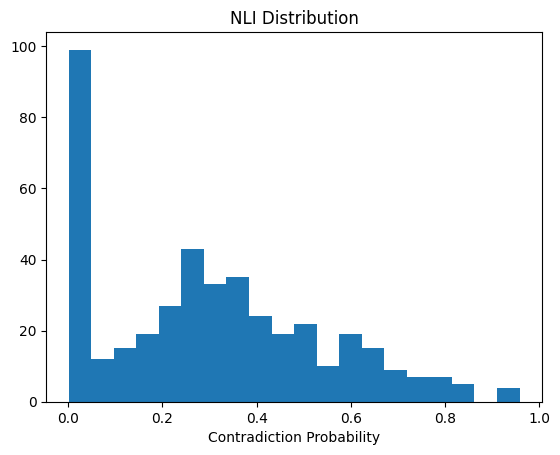

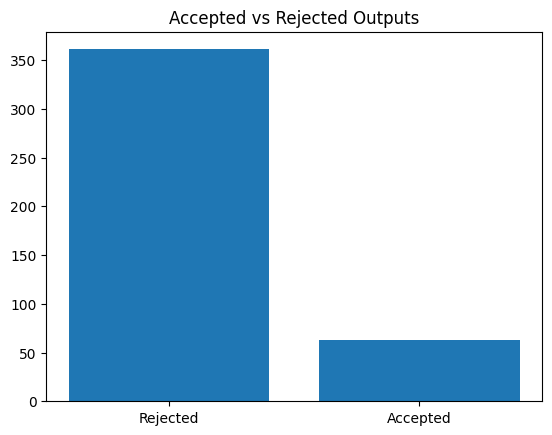


✅ FULL EVALUATION COMPLETE



In [ ]:
# =========================
# 🔷 CELL — FULL EVALUATION SUITE (PAPER-READY)
# =========================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, precision_recall_curve
)

print("\n📊 RUNNING FULL EVALUATION SUITE...\n")

# =========================
# 🔹 1. BIAS DETECTION (BACKBONE PERFORMANCE)
# =========================

print("🔷 1. BIAS DETECTION METRICS\n")

# Assume ground truth exists
if "label" in master_df.columns:

    y_true = master_df["label"]
    y_prob = master_df["p_bias"]

    y_pred = (y_prob >= THRESHOLD).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f} ⭐")
    print(f"ROC-AUC  : {roc_auc:.4f}\n")

    print("Confusion Matrix:")
    print(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}\n")

    # Confusion Matrix Plot
    plt.figure()
    plt.imshow([[tn, fp],[fn, tp]])
    plt.title("Confusion Matrix")
    plt.colorbar()
    plt.xticks([0,1], ["Neg","Pos"])
    plt.yticks([0,1], ["Neg","Pos"])
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.title("ROC Curve")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.show()

    # Precision-Recall Curve
    p, r, _ = precision_recall_curve(y_true, y_prob)
    plt.figure()
    plt.plot(r, p)
    plt.title("Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

else:
    print("⚠ No ground truth labels found — skipping bias detection evaluation\n")


# =========================
# 🔹 2. REWRITING PERFORMANCE
# =========================

print("\n🔷 2. REWRITING PERFORMANCE\n")

bias_before = eval_df["bias_before"]
bias_after  = eval_df["bias_after"]

bias_reduction = bias_before - bias_after
bias_reduction_pct = (bias_reduction / bias_before).mean() * 100

success_rate = eval_df["accepted"].mean() * 100

print(f"Avg Bias Before : {bias_before.mean():.4f}")
print(f"Avg Bias After  : {bias_after.mean():.4f}")
print(f"Bias Reduction  : {bias_reduction.mean():.4f}")
print(f"Bias Reduction %: {bias_reduction_pct:.2f}%")
print(f"Success Rate    : {success_rate:.2f}%\n")

# Before vs After
plt.figure()
plt.scatter(bias_before, bias_after)
plt.xlabel("Before")
plt.ylabel("After")
plt.title("Bias Before vs After")
plt.show()

# Effectiveness Histogram
plt.figure()
plt.hist(bias_reduction, bins=20)
plt.title("Neutralization Effectiveness")
plt.xlabel("Bias Reduction")
plt.show()


# =========================
# 🔹 3. SEMANTIC CONSISTENCY
# =========================

print("\n🔷 3. SEMANTIC CONSISTENCY\n")

sim_scores = eval_df["similarity"]

print(f"Average Similarity: {sim_scores.mean():.4f}")

plt.figure()
plt.hist(sim_scores, bins=20)
plt.title("Similarity Distribution")
plt.xlabel("Cosine Similarity")
plt.show()


# =========================
# 🔹 4. VERIFICATION RESULTS
# =========================

print("\n🔷 4. VERIFICATION RESULTS\n")

contr = eval_df["contradiction"]

contr_rate = (contr > 0.4).mean() * 100
entail_rate = (contr < 0.2).mean() * 100
neutral_rate = 100 - contr_rate - entail_rate

val_acc = eval_df["accepted"].mean() * 100

print(f"Contradiction Rate : {contr_rate:.2f}%")
print(f"Entailment Rate    : {entail_rate:.2f}%")
print(f"Neutral Rate       : {neutral_rate:.2f}%")
print(f"Validation Accuracy: {val_acc:.2f}%\n")

# NLI Distribution
plt.figure()
plt.hist(contr, bins=20)
plt.title("NLI Distribution")
plt.xlabel("Contradiction Probability")
plt.show()

# Accepted vs Rejected
plt.figure()
counts = eval_df["accepted"].value_counts()
plt.bar(["Rejected","Accepted"], counts.values)
plt.title("Accepted vs Rejected Outputs")
plt.show()


print("\n✅ FULL EVALUATION COMPLETE\n")

In [ ]:
# =========================
# 🔷 FINAL DIAGNOSTIC CELL (FIXED)
# =========================

import numpy as np

print("===== DATASET OVERVIEW =====")
total_samples = len(master_df)
rewrites_attempted = len(rewrite_df)

print(f"Total Samples: {total_samples}")
print(f"Rewrites Attempted: {rewrites_attempted}")
print(f"Rewrite Ratio: {rewrites_attempted / total_samples:.2f}")

# -------------------------
# Core Metrics
# -------------------------
print("\n===== CORE METRICS =====")

acceptance_rate = rewrite_df["accepted"].mean() * 100
avg_similarity = rewrite_df["similarity"].mean()
avg_bias_delta = rewrite_df["bias_delta"].mean()
avg_contradiction = rewrite_df["contradiction"].mean()

print(f"Acceptance Rate: {acceptance_rate:.2f}%")
print(f"Average Similarity: {avg_similarity:.4f}")
print(f"Average Bias Reduction: {avg_bias_delta:.4f}")
print(f"Average Contradiction: {avg_contradiction:.4f}")

# -------------------------
# Accepted-only Metrics
# -------------------------
print("\n===== ACCEPTED-ONLY METRICS =====")

accepted_df = rewrite_df[rewrite_df["accepted"] == True]

if len(accepted_df) > 0:
    print(f"Accepted Count: {len(accepted_df)}")
    print(f"Avg Similarity (Accepted): {accepted_df['similarity'].mean():.4f}")
    print(f"Avg Bias Reduction (Accepted): {accepted_df['bias_delta'].mean():.4f}")
    print(f"Avg Contradiction (Accepted): {accepted_df['contradiction'].mean():.4f}")
else:
    print("No accepted samples")

# -------------------------
# Threshold Checks
# -------------------------
print("\n===== THRESHOLD QUALITY CHECK =====")

sim_pass = (rewrite_df["similarity"] >= 0.7).mean() * 100
contr_pass = (rewrite_df["contradiction"] <= 0.1).mean() * 100
bias_pass = (rewrite_df["bias_delta"] > 0).mean() * 100

print(f"Similarity >= 0.7: {sim_pass:.2f}%")
print(f"Contradiction <= 0.1: {contr_pass:.2f}%")
print(f"Bias Reduction > 0: {bias_pass:.2f}%")

# -------------------------
# Failure Analysis
# -------------------------
print("\n===== FAILURE ANALYSIS =====")

failed_df = rewrite_df[rewrite_df["accepted"] == False]

if len(failed_df) > 0:
    print(f"Low Similarity Failures: {(failed_df['similarity'] < 0.7).mean()*100:.2f}%")
    print(f"High Contradiction Failures: {(failed_df['contradiction'] > 0.1).mean()*100:.2f}%")
    print(f"No Bias Reduction Failures: {(failed_df['bias_delta'] <= 0).mean()*100:.2f}%")
else:
    print("No failures")

# -------------------------
# Best / Worst Examples (FIXED)
# -------------------------
print("\n===== BEST / WORST CASES =====")

cols_to_show = ["original", "final_rewrite", "bias_delta"]

available_cols = [c for c in cols_to_show if c in rewrite_df.columns]

best_case = rewrite_df.sort_values("bias_delta", ascending=False).iloc[0]
worst_case = rewrite_df.sort_values("bias_delta").iloc[0]

print("\nBest Bias Reduction:")
print(best_case[available_cols])

print("\nWorst Bias Reduction:")
print(worst_case[available_cols])

# -------------------------
# Final Summary
# -------------------------
print("\n===== FINAL SUMMARY =====")

print(f"""
Acceptance Rate      : {acceptance_rate:.2f}%
Avg Similarity       : {avg_similarity:.4f}
Avg Bias Reduction   : {avg_bias_delta:.4f}
Avg Contradiction    : {avg_contradiction:.4f}
""")

===== DATASET OVERVIEW =====
Total Samples: 1414
Rewrites Attempted: 424
Rewrite Ratio: 0.30

===== CORE METRICS =====
Acceptance Rate: 14.86%
Average Similarity: 0.2695
Average Bias Reduction: 0.3105
Average Contradiction: 0.3019

===== ACCEPTED-ONLY METRICS =====
Accepted Count: 63
Avg Similarity (Accepted): 0.8207
Avg Bias Reduction (Accepted): 0.3021
Avg Contradiction (Accepted): 0.0247

===== THRESHOLD QUALITY CHECK =====
Similarity >= 0.7: 21.23%
Contradiction <= 0.1: 26.42%
Bias Reduction > 0: 96.46%

===== FAILURE ANALYSIS =====
Low Similarity Failures: 91.14%
High Contradiction Failures: 85.32%
No Bias Reduction Failures: 4.16%

===== BEST / WORST CASES =====

Best Bias Reduction:
original         Trump has repeatedly boasted about and taken c...
final_rewrite                                             Revised:
bias_delta                                                0.619286
Name: 184, dtype: object

Worst Bias Reduction:
original         The Trump administration has contin

✔ Comparison dataframe ready: (424, 14)

===== FINAL METRICS =====
Similarity (Multi): 0.2694574872225101
Similarity (Single): 0.12658054159980547

Bias Reduction (Multi): 0.3104509544930611
Bias Reduction (Single): 0.26878077346015833

Contradiction (Multi): 0.3018947883741381
Contradiction (Single): 0.5107282024579242

--- Improvements ---
Similarity Gain: 0.14287694562270464
Bias Gain: 0.04167018103290281
Contradiction Reduction: 0.20883341408378603

Acceptance Rate (Multi): 0.14858490566037735


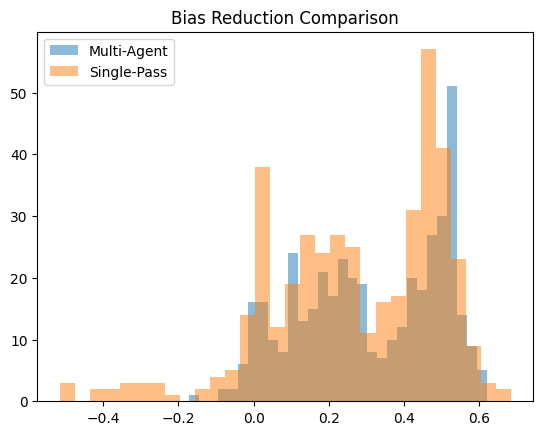

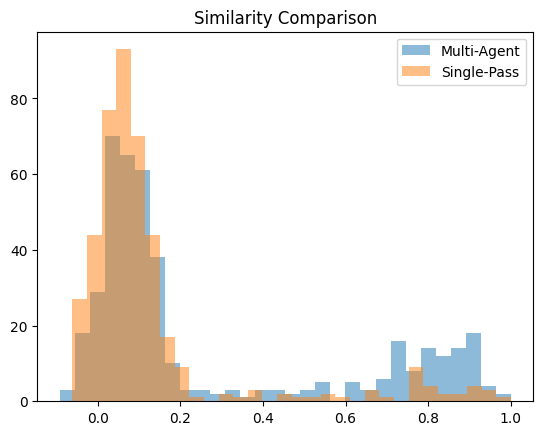

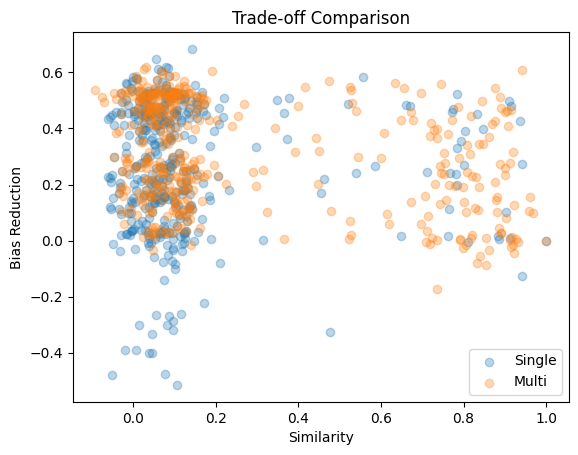


===== TABLE =====
           Metric  Single-Pass  Multi-Agent
0      Similarity     0.126581     0.269457
1  Bias Reduction     0.268781     0.310451
2   Contradiction     0.510728     0.301895


In [ ]:
# =========================
# 🔷 FINAL EVALUATION PIPELINE (CLEAN)
# =========================

import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Load Data
# -------------------------
multi_df = eval_df.copy()
single_df = single_df.copy()

# Rename for clarity
multi_df = multi_df.rename(columns={
    "similarity": "multi_similarity",
    "bias_delta": "multi_bias_delta",
    "contradiction": "multi_contradiction"
})

single_df = single_df.rename(columns={
    "similarity": "single_similarity",
    "bias_delta": "single_bias_delta",
    "contradiction": "single_contradiction"
})

# -------------------------
# Merge
# -------------------------
compare_df = multi_df.merge(single_df, on="sentence_id")

print("✔ Comparison dataframe ready:", compare_df.shape)

# -------------------------
# Compute Gains
# -------------------------
compare_df["sim_gain"] = (
    compare_df["multi_similarity"] - compare_df["single_similarity"]
)

compare_df["bias_gain"] = (
    compare_df["multi_bias_delta"] - compare_df["single_bias_delta"]
)

compare_df["contra_reduction"] = (
    compare_df["single_contradiction"] - compare_df["multi_contradiction"]
)

# -------------------------
# Summary Metrics
# -------------------------
print("\n===== FINAL METRICS =====")

print("Similarity (Multi):", compare_df["multi_similarity"].mean())
print("Similarity (Single):", compare_df["single_similarity"].mean())

print("\nBias Reduction (Multi):", compare_df["multi_bias_delta"].mean())
print("Bias Reduction (Single):", compare_df["single_bias_delta"].mean())

print("\nContradiction (Multi):", compare_df["multi_contradiction"].mean())
print("Contradiction (Single):", compare_df["single_contradiction"].mean())

print("\n--- Improvements ---")
print("Similarity Gain:", compare_df["sim_gain"].mean())
print("Bias Gain:", compare_df["bias_gain"].mean())
print("Contradiction Reduction:", compare_df["contra_reduction"].mean())

if "accepted" in compare_df.columns:
    print("\nAcceptance Rate (Multi):", compare_df["accepted"].mean())

# -------------------------
# Plots
# -------------------------

# Bias Reduction
plt.figure()
plt.hist(compare_df["multi_bias_delta"], bins=30, alpha=0.5)
plt.hist(compare_df["single_bias_delta"], bins=30, alpha=0.5)
plt.legend(["Multi-Agent", "Single-Pass"])
plt.title("Bias Reduction Comparison")
plt.show()

# Similarity
plt.figure()
plt.hist(compare_df["multi_similarity"], bins=30, alpha=0.5)
plt.hist(compare_df["single_similarity"], bins=30, alpha=0.5)
plt.legend(["Multi-Agent", "Single-Pass"])
plt.title("Similarity Comparison")
plt.show()

# Trade-off
plt.figure()
plt.scatter(compare_df["single_similarity"],
            compare_df["single_bias_delta"], alpha=0.3)
plt.scatter(compare_df["multi_similarity"],
            compare_df["multi_bias_delta"], alpha=0.3)
plt.xlabel("Similarity")
plt.ylabel("Bias Reduction")
plt.legend(["Single", "Multi"])
plt.title("Trade-off Comparison")
plt.show()

# -------------------------
# Table for Paper
# -------------------------
summary_df = pd.DataFrame({
    "Metric": ["Similarity", "Bias Reduction", "Contradiction"],
    "Single-Pass": [
        compare_df["single_similarity"].mean(),
        compare_df["single_bias_delta"].mean(),
        compare_df["single_contradiction"].mean()
    ],
    "Multi-Agent": [
        compare_df["multi_similarity"].mean(),
        compare_df["multi_bias_delta"].mean(),
        compare_df["multi_contradiction"].mean()
    ]
})

print("\n===== TABLE =====")
print(summary_df)

In [ ]:
# =========================
# 🔷 FINAL CELL — Load Rewrites + Evaluate (FULL FIXED VERSION)
# =========================

import os
import pandas as pd
from tqdm import tqdm

print("\n📊 Running Final Evaluation Metrics...\n")

# -------------------------
# 🔷 STEP 1: Select correct rewrite file
# -------------------------
priority_files = [
    "final_all_424.csv",
    "rewrite_final.csv",
    "single_agent_424.csv"
]

rewrite_path = None
for fname in priority_files:
    path = os.path.join(PATHS["rewriting"], fname)
    if os.path.exists(path):
        rewrite_path = path
        break

if rewrite_path is None:
    print("\n❌ Could not find valid rewrite file.")
    print("Available files:", os.listdir(PATHS["rewriting"]))
    raise ValueError("Stopping evaluation.")

print(f"✔ Using rewrite file: {rewrite_path}")

rewrite_df = pd.read_csv(rewrite_path)

# -------------------------
# 🔷 DEBUG: Inspect rewrite file
# -------------------------
print("\n🔍 Rewrite file columns:")
print(list(rewrite_df.columns))

print("\n🔍 Sample rows:")
display(rewrite_df.head())

# -------------------------
# 🔷 STEP 2: Detect rewrite column
# -------------------------
possible_rewrite_cols = [
    "rewrite",
    "rewritten",
    "rewritten_text",
    "final_rewrite",
    "output",
    "generated_text"
]

rewrite_col = None
for col in possible_rewrite_cols:
    if col in rewrite_df.columns:
        rewrite_col = col
        break

if rewrite_col is None:
    print("\n❌ Could not find rewrite column.")
    raise ValueError("Stopping evaluation.")

print(f"✔ Using rewrite column: {rewrite_col}")

# -------------------------
# 🔷 STEP 3: Detect merge key
# -------------------------
possible_keys = ["sentence_id", "id", "index"]

merge_key = None
for k in possible_keys:
    if k in rewrite_df.columns and k in master_df.columns:
        merge_key = k
        break

if merge_key is None:
    print("\n❌ Could not find common merge key.")
    print("master_df columns:", list(master_df.columns))
    print("rewrite_df columns:", list(rewrite_df.columns))
    raise ValueError("Fix merge key manually.")

print(f"✔ Using merge key: {merge_key}")

# -------------------------
# 🔷 STEP 4: Merge
# -------------------------
merged_df = master_df.merge(
    rewrite_df[[merge_key, rewrite_col]],
    on=merge_key,
    how="left"
)

print("✔ Merge complete")

# -------------------------
# 🔷 STEP 5: Filter valid rewrites
# -------------------------
eval_df = merged_df[merged_df[rewrite_col].notnull()].copy()

print(f"\nTotal merged rows: {len(merged_df)}")
print(f"Valid rewrites found: {len(eval_df)}")

if len(eval_df) == 0:
    print("\n❌ No valid rewritten samples after merge.")
    print("\n👉 Likely causes:")
    print("- Wrong merge key")
    print("- Rewrite file uses different indexing")
    print("- Rewrite column mismatch")
    raise ValueError("Stopping evaluation.")

print(f"\nEvaluating {len(eval_df)} rewritten samples...\n")

# -------------------------
# 🔷 STEP 6: Evaluation loop
# -------------------------
records = []

for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):

    original = row["text"]
    rewritten = row[rewrite_col]
    bias_before = row["p_bias"]

    sim = compute_similarity(original, rewritten)
    contradiction = compute_contradiction(original, rewritten)
    bias_after = compute_bias(rewritten)

    bias_delta = bias_before - bias_after

    # Adaptive similarity threshold
    sim_threshold = 0.70 if bias_delta >= 0.1 else 0.75

    accepted = (
        sim >= sim_threshold and
        contradiction <= CONFIG["thresholds"]["contradiction"] and
        bias_delta >= CONFIG["thresholds"]["bias_min_delta"]
    )

    records.append({
        "similarity": sim,
        "contradiction": contradiction,
        "bias_before": bias_before,
        "bias_after": bias_after,
        "bias_reduction": bias_delta,
        "accepted": accepted
    })

# -------------------------
# 🔷 STEP 7: Aggregate results
# -------------------------
results_df = pd.DataFrame(records)

summary = {
    "Similarity_mean": results_df["similarity"].mean(),
    "Similarity_std": results_df["similarity"].std(),

    "Contradiction_mean": results_df["contradiction"].mean(),
    "Contradiction_std": results_df["contradiction"].std(),

    "Bias_before_mean": results_df["bias_before"].mean(),
    "Bias_after_mean": results_df["bias_after"].mean(),

    "Bias_reduction_mean": results_df["bias_reduction"].mean(),
    "Bias_reduction_std": results_df["bias_reduction"].std(),

    "Acceptance_rate": results_df["accepted"].mean(),

    "Total_samples": len(results_df)
}

summary_df = pd.DataFrame([summary])

# -------------------------
# 🔷 STEP 8: Display
# -------------------------
print("\n📊 ===== FINAL METRICS =====\n")
display(summary_df)

# -------------------------
# 🔷 STEP 9: Save outputs
# -------------------------
results_path = f"{PATHS['rewriting']}/final_detailed_results.csv"
summary_path = f"{PATHS['rewriting']}/final_summary_metrics.csv"

results_df.to_csv(results_path, index=False)
summary_df.to_csv(summary_path, index=False)

print(f"\n💾 Saved detailed results → {results_path}")
print(f"💾 Saved summary → {summary_path}")

# -------------------------
# 🔷 STEP 10: Diagnostics
# -------------------------
print("\n📈 Acceptance Breakdown:")
print(results_df["accepted"].value_counts(normalize=True))

print("\n📉 Distribution Summary:")
display(results_df.describe())


📊 Running Final Evaluation Metrics...

✔ Using rewrite file: /content/drive/MyDrive/AgenticNeutralizer/rewriting/final_all_424.csv

🔍 Rewrite file columns:
['sentence_id', 'original', 'final_rewrite', 'accepted', 'similarity', 'bias_before', 'bias_after', 'bias_delta', 'contradiction']

🔍 Sample rows:


,sentence_id,original,final_rewrite,accepted,similarity,bias_before,bias_after,bias_delta,contradiction
0,0_mbic,YouTube is making clear there will be no “birt...,Neutral:,False,0.052227,0.740888,0.263455,0.477434,0.492896
1,1_mbic,The increasingly bitter dispute between Americ...,Rewritten: The U.S. Soccer Federation and the ...,True,0.744763,0.538899,0.297925,0.240974,0.002927
2,3_mbic,A professor who teaches climate change classes...,Revised:,False,0.050649,0.420229,0.261327,0.158902,0.382939
3,4_mbic,"Looking around the United States, there is nev...",Rewritten:,False,0.075569,0.792506,0.268454,0.524051,0.442741
4,6_mbic,The Republican president assumed he was helpin...,Revised: The Republican president's approach t...,False,0.720502,0.791179,0.372299,0.418880,0.755788


✔ Using rewrite column: final_rewrite
✔ Using merge key: sentence_id
✔ Merge complete

Total merged rows: 1414
Valid rewrites found: 424

Evaluating 424 rewritten samples...



100%|██████████| 424/424 [00:19<00:00, 21.32it/s]


📊 ===== FINAL METRICS =====



,Similarity_mean,Similarity_std,Contradiction_mean,Contradiction_std,Bias_before_mean,Bias_after_mean,Bias_reduction_mean,Bias_reduction_std,Acceptance_rate,Total_samples
0,0.269457,0.322997,0.301895,0.234539,0.61958,0.309129,0.310451,0.18597,0.136792,424



💾 Saved detailed results → /content/drive/MyDrive/AgenticNeutralizer/rewriting/final_detailed_results.csv
💾 Saved summary → /content/drive/MyDrive/AgenticNeutralizer/rewriting/final_summary_metrics.csv

📈 Acceptance Breakdown:
accepted
False    0.863208
True     0.136792
Name: proportion, dtype: float64

📉 Distribution Summary:


,similarity,contradiction,bias_before,bias_after,bias_reduction
count,424.000000,424.000000,424.000000,424.000000,424.000000
mean,0.269457,0.301895,0.619580,0.309129,0.310451
std,0.322997,0.234539,0.174026,0.111315,0.185970
min,-0.091350,0.001213,0.246842,0.202258,-0.172749
25%,0.048062,0.071707,0.478933,0.261327,0.157384
50%,0.103899,0.286439,0.665824,0.267151,0.298060
75%,0.527585,0.460645,0.779092,0.328355,0.490146
max,1.000000,0.957783,0.914413,0.864456,0.619286


In [ ]:
# =========================
# 🔷 FINAL EVALUATION CELL — FULLY CORRECT (NO ASSUMPTIONS)
# =========================

import os
import pandas as pd

print("\n📊 Running FINAL Aggregation (Fully Correct)...\n")

# -------------------------
# Load files
# -------------------------
proposed_path = os.path.join(PATHS["rewriting"], "final_all_424.csv")
baseline_path = os.path.join(PATHS["rewriting"], "single_agent_424.csv")

proposed_df = pd.read_csv(proposed_path)
baseline_df = pd.read_csv(baseline_path)

print("✔ Files loaded")

# -------------------------
# 🔷 Ensure bias_before exists
# -------------------------
def attach_bias_before(df, name):

    if "bias_before" in df.columns:
        return df

    print(f"⚠ '{name}' missing bias_before → merging from master_df")

    if "sentence_id" not in df.columns:
        raise ValueError(f"{name} missing sentence_id — cannot merge")

    df = df.merge(
        master_df[["sentence_id", "p_bias"]],
        on="sentence_id",
        how="left"
    )

    df = df.rename(columns={"p_bias": "bias_before"})

    return df

proposed_df = attach_bias_before(proposed_df, "proposed")
baseline_df = attach_bias_before(baseline_df, "baseline")

# -------------------------
# 🔷 Ensure bias_delta exists
# -------------------------
def ensure_bias_delta(df):
    if "bias_delta" not in df.columns:
        df["bias_delta"] = df["bias_before"] - df["bias_after"]
    return df

proposed_df = ensure_bias_delta(proposed_df)
baseline_df = ensure_bias_delta(baseline_df)

# -------------------------
# 🔷 Ensure accepted exists
# -------------------------
def ensure_accepted(df, name):

    if "accepted" in df.columns:
        return df

    print(f"⚠ '{name}' missing accepted → computing")

    df["accepted"] = (
        (df["similarity"] >= 0.75) &
        (df["contradiction"] <= 0.35) &
        (df["bias_delta"] >= 0.02)
    )

    return df

proposed_df = ensure_accepted(proposed_df, "proposed")
baseline_df = ensure_accepted(baseline_df, "baseline")

# -------------------------
# 🔷 Summary function
# -------------------------
def summarize(df):

    acc_df = df[df["accepted"] == True]

    summary = {
        "Similarity": df["similarity"].mean(),
        "Contradiction": df["contradiction"].mean(),
        "Bias_Reduction": df["bias_delta"].mean(),

        "Bias_Reduction_%": (df["bias_delta"].mean() / df["bias_before"].mean()) * 100,

        "Acceptance_Rate": df["accepted"].mean(),

        "Sim_Accepted": acc_df["similarity"].mean() if len(acc_df)>0 else 0,
        "Contr_Accepted": acc_df["contradiction"].mean() if len(acc_df)>0 else 0,
        "BiasRed_Accepted": acc_df["bias_delta"].mean() if len(acc_df)>0 else 0,

        "Sim_Pass": (df["similarity"] >= 0.75).mean(),
        "Contr_Pass": (df["contradiction"] <= 0.35).mean(),
        "Bias_Pass": (df["bias_delta"] >= 0.02).mean(),

        "Total": len(df)
    }

    return summary

# -------------------------
# Compute summaries
# -------------------------
prop_summary = summarize(proposed_df)
base_summary = summarize(baseline_df)

# -------------------------
# Comparison table
# -------------------------
comparison = pd.DataFrame([
    {"Method": "Proposed", **prop_summary},
    {"Method": "Baseline", **base_summary}
])

print("\n📊 ===== FINAL COMPARISON =====\n")
display(comparison)

# -------------------------
# Save
# -------------------------
comparison.to_csv(f"{PATHS['rewriting']}/final_comparison.csv", index=False)

print("\n💾 Saved final comparison")

# -------------------------
# LaTeX output
# -------------------------
print("\n📄 ===== LATEX TABLE =====\n")

for _, row in comparison.iterrows():
    print(
        f"{row['Method']} & "
        f"{row['Similarity']:.3f} & "
        f"{row['Contradiction']:.3f} & "
        f"{row['Bias_Reduction_%']:.2f}\\% & "
        f"{row['Acceptance_Rate']:.2f} \\\\"
    )


📊 Running FINAL Aggregation (Fully Correct)...

✔ Files loaded
⚠ 'baseline' missing bias_before → merging from master_df
⚠ 'baseline' missing accepted → computing

📊 ===== FINAL COMPARISON =====



,Method,Similarity,Contradiction,Bias_Reduction,Bias_Reduction_%,Acceptance_Rate,Sim_Accepted,Contr_Accepted,BiasRed_Accepted,Sim_Pass,Contr_Pass,Bias_Pass,Total
0,Proposed,0.269457,0.301895,0.310451,50.106714,0.148585,0.820722,0.024664,0.302051,0.169811,0.617925,0.926887,424
1,Baseline,0.126581,0.510728,0.268781,43.381156,0.042453,0.827492,0.014431,0.345096,0.058962,0.278302,0.867925,424



💾 Saved final comparison

📄 ===== LATEX TABLE =====

Proposed & 0.269 & 0.302 & 50.11\% & 0.15 \\
Baseline & 0.127 & 0.511 & 43.38\% & 0.04 \\
